
CAPSTONE ANALYSIS - TRIPLE POWER LAW FIT
After filtering for Mstar ≤ 2.0 M☉: 944 data points
After dropping NaN in required columns: 578 data points

TRIPLE POWER LAW FIT WITH ALL THREE VARIABLES
Using 578 valid data points for fitting
Filtered out 0 points with Mstar <= 0
[[Model]]
    Model(triple_power_law)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 578
    # variables        = 3
    chi-square         = 169.364603
    reduced chi-square = 0.29454713
    Akaike info crit   = -703.506598
    Bayesian info crit = -690.427876
    R-squared          = 0.17038413
[[Variables]]
    log_amplitude: -5.62291174 +/- 0.31141239 (5.54%) (init = -7)
    age_exponent:  -0.41111783 +/- 0.04746726 (11.55%) (init = -1)
    mass_exponent:  1.13654862 +/- 0.11106563 (9.77%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(log_amplitude, age_exponent)  = -0.9963
    C(log_amplitude, mass_exponent) = +0.5835
    C(age_

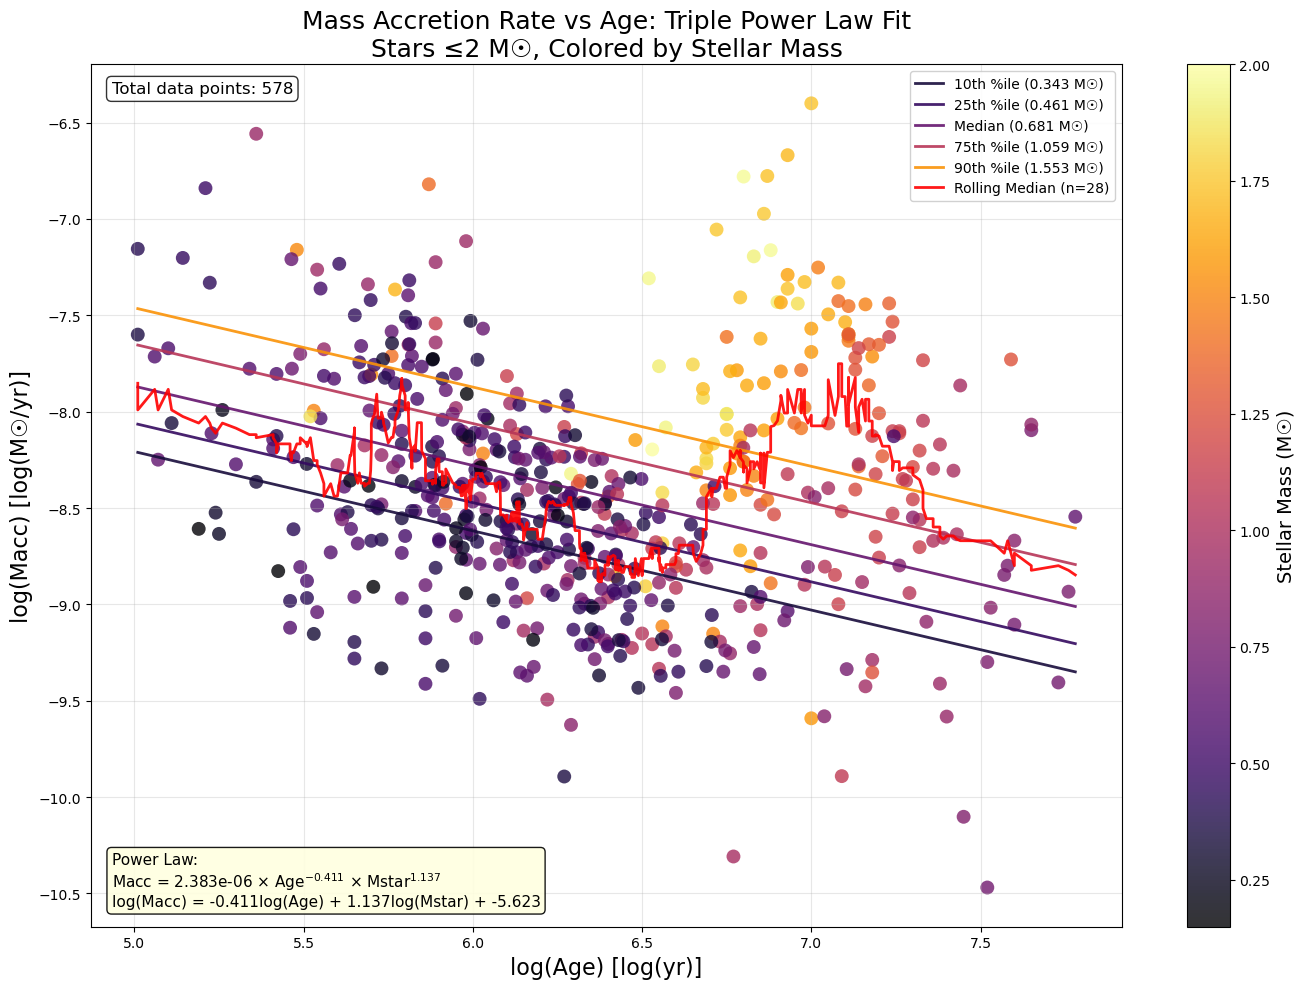

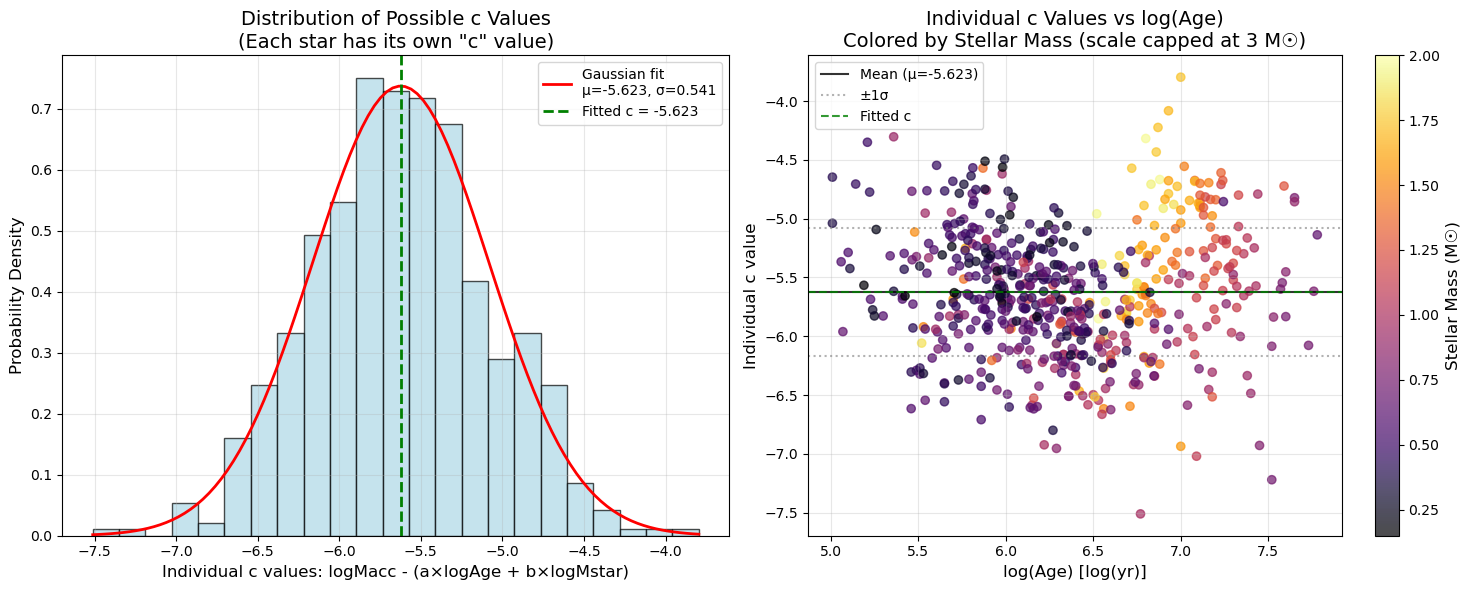

In [1]:
"""
Capstone Code - Triple Power Law Fit Code, Plotting + Distribution of possible amplitudes
Date: Nov 17 2025
Updated: June 29 2026

Input Files:
compilation_Venuti_2024_Serna_2021.csv

Output Files:
power_law_model.npy (Section 4)
stellar_accretion_data.csv (Section 4)
Capstone_Report_Final.pdf (Section 5) - only if user prompts

1 - power_law_model.npy: 
    Contains the fitted power law coefficients, uncertainty parameters, and data ranges for realistic synthetic generation.
    Stores calibrated power-law model so that just the model can be used for synthetic data generation without needing to 
    rerun the entire analysis.

2 - stellar_accretion_data.csv: 
    Contains the original data, calculated processed columns (including linear data), and individual c values for each star. 
    Gives cleaned data - reusable.
    
3 - Capstone_Report_Final.pdf: 
    A comprehensive PDF report containing all results, plots, and interpretations. For ease of reading and distribution.

This has 6 sections:
1 - Mathematical calculation of the triple power law fit
2 - Plotting of triple power law graph
3 - c-Value extraction and distribution plotting
4 - Interpretation of c-Value Distribution
5 - PDF Generation
6 - Summary
"""

import matplotlib.pyplot as plt
import numpy as np
import lmfit
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import norm
from datetime import datetime


def load_and_filter_data(file_path):
    """
    Load the dataset and apply filters for stellar mass and data quality.
    
    Parameters:
        file_path (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: Filtered dataframe with required columns
    """
    df = pd.read_csv(file_path)
    
    # Filter for stars ≤2 solar masses
    df = df[df['Mstar'] <= 2.0]
    print(f"After filtering for Mstar ≤ 2.0 M☉: {len(df)} data points")
    
    # Remove rows with missing data
    df = df.dropna(subset=['logAge', 'Mstar', 'logMacc'])
    print(f"After dropping NaN in required columns: {len(df)} data points")
    
    # Transform log-scaled variables to linear form
    df['Age_linear'] = 10**df['logAge']
    df['Macc_linear'] = 10**df['logMacc']
    df['logMstar'] = np.log10(df['Mstar'])
    
    return df


def triple_power_law(log_age, log_mstar, log_amplitude, age_exponent, mass_exponent):
    """
    Triple power law model for mass accretion rate.
    
    Parameters:
        log_age (float): log10(stellar age in years)
        log_mstar (float): log10(stellar mass in solar masses)
        log_amplitude (float): log10(normalization constant)
        age_exponent (float): Power law exponent for age dependence
        mass_exponent (float): Power law exponent for mass dependence
        
    Returns:
        float: log10(mass accretion rate in solar masses/year)
    """
    return log_amplitude + age_exponent * log_age + mass_exponent * log_mstar


def fit_triple_power_law(df):
    """
    Fit the triple power law model to the data using lmfit.
    
    Parameters:
        df (pd.DataFrame): Input data with logAge, logMstar, logMacc columns
        
    Returns:
        tuple: (result, log_amp, age_exp, mass_exp, amp_linear)
    """
    # Prepare data
    log_age_data = np.array(df['logAge'].values, dtype=float)
    log_mstar_data = np.array(df['logMstar'].values, dtype=float)
    log_macc_data = np.array(df['logMacc'].values, dtype=float)
    
    # Remove invalid mass values
    valid_mask = (df['Mstar'].values > 0)
    log_age_data = log_age_data[valid_mask]
    log_mstar_data = log_mstar_data[valid_mask]
    log_macc_data = log_macc_data[valid_mask]
    
    print(f"Using {len(log_age_data)} valid data points for fitting")
    print(f"Filtered out {len(df) - len(log_age_data)} points with Mstar <= 0")
    
    # Create model and parameters
    model = lmfit.Model(triple_power_law, independent_vars=['log_age', 'log_mstar'])
    
    params = model.make_params()
    params.add('log_amplitude', value=-7, min=-12, max=5)
    params.add('age_exponent', value=-1.0, min=-30.0, max=30.0)
    params.add('mass_exponent', value=1.0, min=-30.0, max=30.0)
    
    # Perform fit
    result = model.fit(log_macc_data, params, 
                      log_age=log_age_data, log_mstar=log_mstar_data)
    
    # Extract parameters
    log_amp = result.params['log_amplitude'].value
    age_exp = result.params['age_exponent'].value
    mass_exp = result.params['mass_exponent'].value
    amp_linear = 10**log_amp
    
    return result, log_amp, age_exp, mass_exp, amp_linear


def compute_c_values(df, age_exp, mass_exp):
    """
    Compute individual c-values from the residual method.
    
    Parameters:
        df (pd.DataFrame): Input data with logAge, logMstar, logMacc columns
        age_exp (float): Fitted age exponent
        mass_exp (float): Fitted mass exponent
        
    Returns:
        np.ndarray: Array of individual c-values
    """
    return df['logMacc'] - (age_exp * df['logAge'] + mass_exp * df['logMstar'])


def fit_c_distribution(c_values):
    """
    Fit a Gaussian distribution to the c-values.
    
    Parameters:
        c_values (np.ndarray): Array of c-values
        
    Returns:
        tuple: (mu, sigma) mean and standard deviation of the Gaussian fit
    """
    return norm.fit(c_values)


def plot_triple_power_law(ax, df, log_amp, age_exp, mass_exp, amp_linear):
    """
    Create the triple power law visualization plot.
    
    Parameters:
        ax (matplotlib.axes.Axes): The axes to plot on
        df (pd.DataFrame): Input data
        log_amp (float): log10(amplitude)
        age_exp (float): Age exponent
        mass_exp (float): Mass exponent
        amp_linear (float): Linear amplitude
        
    Returns:
        matplotlib.axes.Axes: The modified axes
    """
    # Color settings
    vmax = 2.0
    vmin = df['Mstar'].min()
    
    # Scatter plot
    scatter = ax.scatter(df['logAge'], df['logMacc'], 
                        c=df['Mstar'], cmap='inferno',
                        vmin=vmin, vmax=vmax,
                        marker='o', edgecolors='none',
                        alpha=0.8, s=100)
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Stellar Mass (M☉)', fontsize=14)
    
    # Fit lines for mass percentiles
    mstar_percentiles = [
        df['Mstar'].quantile(0.10),
        df['Mstar'].quantile(0.25),
        df['Mstar'].quantile(0.50),
        df['Mstar'].quantile(0.75),
        df['Mstar'].quantile(0.90)
    ]
    labels = ['10th %ile', '25th %ile', 'Median', '75th %ile', '90th %ile']
    
    x_fit_log = np.linspace(df['logAge'].min(), df['logAge'].max(), 100)
    age_fit_linear = 10**x_fit_log
    
    norm_colors = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.inferno
    colors = [cmap(norm_colors(mstar)) for mstar in mstar_percentiles]
    
    for mstar, color, label in zip(mstar_percentiles, colors, labels):
        macc_fit = np.maximum(
            amp_linear * np.power(age_fit_linear, age_exp) * np.power(mstar, mass_exp), 
            1e-10
        )
        ax.plot(x_fit_log, np.log10(macc_fit), color=color, linewidth=2, 
                linestyle='-', alpha=0.9, label=f'{label} ({mstar:.3f} M☉)')
    
    # Rolling median
    df_sorted = df.sort_values('logAge').copy()
    window_size = max(int(len(df) * 0.05), 5)
    df_sorted['rolling_median_logMacc'] = df_sorted['logMacc'].rolling(
        window=window_size, center=True, min_periods=1
    ).median()
    
    ax.plot(df_sorted['logAge'], df_sorted['rolling_median_logMacc'], 
            color='red', linewidth=2, linestyle='-', alpha=0.9,
            label=f'Rolling Median (n={window_size})')
    
    # Labels and title
    ax.set_xlabel('log(Age) [log(yr)]', fontsize=16)
    ax.set_ylabel('log(Macc) [log(M☉/yr)]', fontsize=16)
    ax.set_title('Mass Accretion Rate vs Age: Triple Power Law Fit\nStars ≤2 M☉, Colored by Stellar Mass', fontsize=18)
    ax.grid(True, alpha=0.3)
    
    # Statistics text
    stats_text = f'Total data points: {len(df)}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', fontsize=12,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Equation text
    eq_text_main = (f'Power Law:\nMacc = {amp_linear:.3e} × Age$^{{{age_exp:.3f}}}$ × Mstar$^{{{mass_exp:.3f}}}$\n'
                   f'log(Macc) = {age_exp:.3f}log(Age) + {mass_exp:.3f}log(Mstar) + {log_amp:.3f}')
    ax.text(0.02, 0.02, eq_text_main, transform=ax.transAxes,
            verticalalignment='bottom', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
    
    ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
    
    return ax


def plot_c_distribution(c_values, log_amp, vmin, vmax):
    """
    Create the c-value distribution visualization.
    
    Parameters:
        c_values (np.ndarray): Array of c-values
        log_amp (float): log10(amplitude) for reference line
        vmin (float): Minimum mass for color scaling
        vmax (float): Maximum mass for color scaling
        
    Returns:
        matplotlib.figure.Figure: The created figure
    """
    mu, sigma = norm.fit(c_values)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Histogram with Gaussian fit
    ax1.hist(c_values, bins='auto', density=True, alpha=0.7, 
             color='lightblue', edgecolor='black')
    
    x = np.linspace(c_values.min(), c_values.max(), 100)
    y = norm.pdf(x, mu, sigma)
    ax1.plot(x, y, 'r-', linewidth=2, label=f'Gaussian fit\nµ={mu:.3f}, σ={sigma:.3f}')
    ax1.axvline(x=log_amp, color='green', linestyle='--', linewidth=2, 
                label=f'Fitted c = {log_amp:.3f}')
    ax1.set_xlabel('Individual c values: logMacc - (a×logAge + b×logMstar)', fontsize=12)
    ax1.set_ylabel('Probability Density', fontsize=12)
    ax1.set_title('Distribution of Possible c Values\n(Each star has its own "c" value)', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # c-values vs age
    scatter2 = ax2.scatter(df['logAge'], c_values, 
                          c=df['Mstar'], cmap='inferno', 
                          vmin=vmin, vmax=vmax, alpha=0.7)
    ax2.axhline(y=mu, color='black', linestyle='-', alpha=0.8, label=f'Mean (µ={mu:.3f})')
    ax2.axhline(y=mu + sigma, color='gray', linestyle=':', alpha=0.6, label=f'±1σ')
    ax2.axhline(y=mu - sigma, color='gray', linestyle=':', alpha=0.6)
    ax2.axhline(y=log_amp, color='green', linestyle='--', alpha=0.8, label=f'Fitted c')
    ax2.set_xlabel('log(Age) [log(yr)]', fontsize=12)
    ax2.set_ylabel('Individual c value', fontsize=12)
    ax2.set_title('Individual c Values vs log(Age)\nColored by Stellar Mass (scale capped at 3 M☉)', fontsize=14)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    cbar2 = plt.colorbar(scatter2, ax=ax2)
    cbar2.set_label('Stellar Mass (M☉)', fontsize=12)
    
    plt.tight_layout()
    return fig


def save_parameters(log_amp, age_exp, mass_exp, mu, sigma, df):
    """Save fitted parameters and model data to files."""
    np.save('power_law_model.npy', {
        'log_amp': log_amp,
        'age_exp': age_exp, 
        'mass_exp': mass_exp,
        'mu': mu,
        'sigma': sigma,
        'age_range': [df['logAge'].min(), df['logAge'].max()],
        'mass_range': [df['Mstar'].min(), df['Mstar'].max()],
        'logMstar_range': [df['logMstar'].min(), df['logMstar'].max()],
        'original_fit_params': [log_amp, age_exp, mass_exp, mu, sigma]
    })
    print("✓ Power law model parameters saved to 'power_law_model.npy'")
    
    df['c_value'] = compute_c_values(df, age_exp, mass_exp)
    df.to_csv('stellar_accretion_data.csv', index=False)
    print("✓ Stellar accretion data with residuals saved to 'stellar_accretion_data.csv'")


def ask_save_pdf():
    """Ask user whether to save PDF report."""
    response = input("\nSave PDF report? (y/n): ").strip().lower()
    return response in ['y', 'yes', '1']


def create_combined_pdf(df, fig, fig_cdist, log_amp, age_exp, mass_exp, amp_linear, 
                        mu, sigma, fraction_explained, total_variance):
    """Create PDF report with plots and text summary."""
    PDF_FILENAME = 'Capstone_Report_Final.pdf'
    
    try:
        with PdfPages(PDF_FILENAME) as pdf:
            # Text summary page
            fig_text, ax_text = plt.subplots(figsize=(8.5, 11))
            ax_text.axis('off')
            
            text_content = [
                "Capstone Project Report",
                "By: Tanay Ayiliath",
                "TRIPLE POWER LAW FIT ANALYSIS RESULTS",
                "=" * 50,
                "",
                "DATA STATISTICS:",
                f"Total data points: {len(df)}",
                f"logMacc range: {df['logMacc'].min():.3f} to {df['logMacc'].max():.3f}",
                f"logAge range: {df['logAge'].min():.3f} to {df['logAge'].max():.3f}",
                f"Mstar range: {df['Mstar'].min():.3f} to {df['Mstar'].max():.3f} Solar Masses",
                "",
                "CORRELATIONS:",
                f"logAge vs logMacc: {df['logAge'].corr(df['logMacc']):.3f}",
                f"logMstar vs logMacc: {df['logMstar'].corr(df['logMacc']):.3f}",
                f"logAge vs logMstar: {df['logAge'].corr(df['logMstar']):.3f}",
                "",
                "TRIPLE POWER LAW FIT RESULTS:",
                f"log(Macc) = {log_amp:.3f} + {age_exp:.3f}×logAge + {mass_exp:.3f}×log(Mstar)",
                f"Macc = {amp_linear:.3e} × Age^{age_exp:.3f} × Mstar^{mass_exp:.3f}",
                "",
                "INTERPRETATION:",
                f"{'→ Mass accretion decreases with age (expected)' if age_exp < 0 else '→ UNEXPECTED: mass accretion increases with age'}",
                f"{'→ More massive stars have higher accretion rates (expected)' if mass_exp > 0 else '→ UNEXPECTED: less massive stars have higher accretion rates'}",
                "",
                "PROBABILISTIC ANALYSIS:",
                f"Individual c values distribution: c ~ N(μ={mu:.3f}, σ={sigma:.3f})",
                f"→ Intrinsic scatter in accretion physics: σ = {sigma:.3f}",
                f"→ 68% of stars have c values within ±{sigma:.3f} of mean",
                f"→ Age & mass explain {fraction_explained*100:.3f}% of variance",
                f"→ Unexplained variance: {(sigma**2/total_variance)*100:.3f}%"
            ]
            
            ax_text.text(0.05, 0.95, '\n'.join(text_content), 
                        transform=ax_text.transAxes, fontsize=10, 
                        verticalalignment='top', fontfamily='monospace')
            
            current_time = datetime.now().strftime("%d-%m-%Y %H:%M:%S")
            ax_text.text(0.95, 0.02, f"Generated: {current_time}", 
                        transform=ax_text.transAxes, fontsize=8,
                        verticalalignment='bottom', horizontalalignment='right',
                        style='italic', alpha=0.7)
            
            pdf.savefig(fig_text, bbox_inches='tight')
            plt.close(fig_text)
            
            # Main plot
            pdf.savefig(fig, bbox_inches='tight')
            
            # c-distribution plot
            if fig_cdist is not None:
                pdf.savefig(fig_cdist, bbox_inches='tight')
            
            d = pdf.infodict()
            d['Title'] = 'Triple Power Law Fit Analysis with Probabilistic Interpretation'
            d['Author'] = 'Tanay Ayiliath'
            d['Subject'] = 'Mass Accretion Rate Analysis with Uncertainty Quantification'
            
        print(f"Combined PDF report successfully saved as: {PDF_FILENAME}")
        
    except Exception as e:
        print(f"Error saving PDF: {e}")
        import traceback
        traceback.print_exc()


def print_summary(df, log_amp, age_exp, mass_exp):
    """Print comprehensive analysis summary."""
    print("\n" + "="*80)
    print("COMPREHENSIVE ANALYSIS SUMMARY")
    print("="*80)
    
    print(f"\nDATA STATISTICS:")
    print(f"Total data points: {len(df)}")
    print(f"logMacc range: {df['logMacc'].min():.3f} to {df['logMacc'].max():.3f}")
    print(f"logAge range: {df['logAge'].min():.3f} to {df['logAge'].max():.3f}")
    print(f"Mstar range: {df['Mstar'].min():.3f} to {df['Mstar'].max():.3f} Solar Masses")
    print(f"logMstar range: {df['logMstar'].min():.3f} to {df['logMstar'].max():.3f} Solar Masses")
    
    print(f"\nCORRELATIONS:")
    print(f"logAge vs logMacc: {df['logAge'].corr(df['logMacc']):.3f}")
    print(f"logMstar vs logMacc: {df['logMstar'].corr(df['logMacc']):.3f}")
    print(f"logAge vs logMstar: {df['logAge'].corr(df['logMstar']):.3f}")
    
    print(f"\nINTERPRETATION:")
    print(f"TRIPLE POWER LAW: log(Macc) = {age_exp:.3f}log(Age) + {mass_exp:.3f}log(Mstar) + {log_amp:.3f}")
    print(f"  → Mass accretion {'decreases' if age_exp < 0 else 'increases (UNEXPECTED)'} with age")
    print(f"  → {'More' if mass_exp > 0 else 'Less (UNEXPECTED)'} massive stars have higher accretion rates")


# ============================================================================
# MAIN EXECUTION
# ============================================================================
print("\n" + "="*60)
print("CAPSTONE ANALYSIS - TRIPLE POWER LAW FIT")
print("="*60)

# Load data
file_path = 'compilation_Venuti_2024_Serna_2021.csv'
df = load_and_filter_data(file_path)

# Create main plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Section 1: Fit the model
print("\n" + "="*60)
print("TRIPLE POWER LAW FIT WITH ALL THREE VARIABLES")
print("="*60)

try:
    result, log_amp, age_exp, mass_exp, amp_linear = fit_triple_power_law(df)
    fit_available = True
    print(result.fit_report())
    print(f"\nBEST-FIT TRIPLE POWER LAW IN LOG SPACE:")
    print(f"logMacc = {log_amp:.3f} + {age_exp:.3f}×logAge + {mass_exp:.3f}×log(Mstar)")
    print(f"Macc = {amp_linear:.3e} × Age^{age_exp:.3f} × Mstar^{mass_exp:.3f}")
except Exception as e:
    print(f"Triple power law analysis failed: {e}")
    fit_available = False
    raise RuntimeError("Triple power law fit failed - cannot continue analysis")

# Section 2: Plot the data
plot_triple_power_law(ax, df, log_amp, age_exp, mass_exp, amp_linear)
plt.tight_layout()

# Section 3: c-value distribution
print("\n" + "="*60)
print("PROBABILISTIC ANALYSIS: DISTRIBUTION OF POSSIBLE c VALUES")
print("="*60)

c_values = compute_c_values(df, age_exp, mass_exp)
mu, sigma = fit_c_distribution(c_values)

print(f"Individual c values statistics:")
print(f"  Mean (µ): {mu:.3f}")
print(f"  Std Dev (σ): {sigma:.3f}")
print(f"  Min c value: {c_values.min():.3f}")
print(f"  Max c value: {c_values.max():.3f}")
print(f"  Original fitted c: {log_amp:.3f}")
print(f"\nGaussian fit to individual c values:")
print(f"  µ (mean): {mu:.3f}")
print(f"  σ (std dev): {sigma:.3f}")
print(f"  Difference from fitted c: {mu - log_amp:.3f}")

# Create c-distribution plot
vmax = 2.0
vmin = df['Mstar'].min()
fig_cdist = plot_c_distribution(c_values, log_amp, vmin, vmax)

# Section 4: Interpretation
print("\n" + "="*50)
print("C AS PROBABILITY DISTRIBUTION: INTERPRETATION")
print("="*50)

print(f"\nThe C Distribution model states:")
print(f"logMacc = {age_exp:.3f}×logAge + {mass_exp:.3f}×logMstar + c")
print(f"where c ~ Normal(µ = {mu:.3f}, σ = {sigma:.3f})")

total_variance = df['logMacc'].var()
explained_variance = (age_exp**2 * df['logAge'].var() + 
                      mass_exp**2 * df['logMstar'].var() + 
                      2 * age_exp * mass_exp * df['logAge'].cov(df['logMstar']))
fraction_explained = explained_variance / total_variance

print(f"\nVariance decomposition:")
print(f"  Total variance in logMacc: {total_variance:.3f}")
print(f"  Variance explained by age & mass: {explained_variance:.3f} ({fraction_explained*100:.3f}%)")
print(f"  Unexplained variance (σ²): {sigma**2:.3f} ({(sigma**2/total_variance)*100:.3f}%)")

# Section 5: Save outputs
save_parameters(log_amp, age_exp, mass_exp, mu, sigma, df)

# Section 6: PDF generation
if ask_save_pdf():
    create_combined_pdf(df, fig, fig_cdist, log_amp, age_exp, mass_exp, amp_linear, 
                        mu, sigma, fraction_explained, total_variance)
else:
    print("PDF report skipped")

# Section 7: Summary
print_summary(df, log_amp, age_exp, mass_exp)

# Show plots
plt.show()